In [1]:
import pandas as pd

In [2]:
#phase 1 data understanding

In [3]:
#reading csv

df_sample = pd.read_csv(r"../data/raw/sample_submission.csv")

df_sample



,Id,SalePrice
0,1461,169277.052498
1,1462,187758.393989
2,1463,183583.683570
3,1464,179317.477511
4,1465,150730.079977
...,...,...
1454,2915,167081.220949
1455,2916,164788.778231
1456,2917,219222.423400
1457,2918,184924.279659


In [4]:
df_test = pd.read_csv(r"../data/raw/test.csv")

In [44]:
df_test.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [48]:
df_test["GarageArea"]

0       730.0
1       312.0
2       482.0
3       470.0
4       506.0
        ...  
1454      0.0
1455    286.0
1456    576.0
1457      0.0
1458    650.0
Name: GarageArea, Length: 1459, dtype: float64

In [6]:
#null values

In [7]:
null_val = [(i,j) for i,j in zip(df_test.columns,df_test.isnull().sum()) if j != 0]
null_val

#total null value
count =0
for i in null_val:
    count += i[1]
print("total null values: ",count)
null_val

total null values:  7878


[('MSZoning', 4),
 ('LotFrontage', 227),
 ('Alley', 1352),
 ('Utilities', 2),
 ('Exterior1st', 1),
 ('Exterior2nd', 1),
 ('MasVnrType', 894),
 ('MasVnrArea', 15),
 ('BsmtQual', 44),
 ('BsmtCond', 45),
 ('BsmtExposure', 44),
 ('BsmtFinType1', 42),
 ('BsmtFinSF1', 1),
 ('BsmtFinType2', 42),
 ('BsmtFinSF2', 1),
 ('BsmtUnfSF', 1),
 ('TotalBsmtSF', 1),
 ('BsmtFullBath', 2),
 ('BsmtHalfBath', 2),
 ('KitchenQual', 1),
 ('Functional', 2),
 ('FireplaceQu', 730),
 ('GarageType', 76),
 ('GarageYrBlt', 78),
 ('GarageFinish', 78),
 ('GarageCars', 1),
 ('GarageArea', 1),
 ('GarageQual', 78),
 ('GarageCond', 78),
 ('PoolQC', 1456),
 ('Fence', 1169),
 ('MiscFeature', 1408),
 ('SaleType', 1)]

In [8]:
df_test.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
count,1459.000000,1459.000000,1232.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1444.000000,1458.000000,...,1458.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000
mean,2190.000000,57.378341,68.580357,9819.161069,6.078821,5.553804,1971.357779,1983.662783,100.709141,439.203704,...,472.768861,93.174777,48.313914,24.243317,1.794380,17.064428,1.744345,58.167923,6.104181,2007.769705
std,421.321334,42.746880,22.376841,4955.517327,1.436812,1.113740,30.390071,21.130467,177.625900,455.268042,...,217.048611,127.744882,68.883364,67.227765,20.207842,56.609763,30.491646,630.806978,2.722432,1.301740
min,1461.000000,20.000000,21.000000,1470.000000,1.000000,1.000000,1879.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000
25%,1825.500000,20.000000,58.000000,7391.000000,5.000000,5.000000,1953.000000,1963.000000,0.000000,0.000000,...,318.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000
50%,2190.000000,50.000000,67.000000,9399.000000,6.000000,5.000000,1973.000000,1992.000000,0.000000,350.500000,...,480.000000,0.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000
75%,2554.500000,70.000000,80.000000,11517.500000,7.000000,6.000000,2001.000000,2004.000000,164.000000,753.500000,...,576.000000,168.000000,72.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000
max,2919.000000,190.000000,200.000000,56600.000000,10.000000,9.000000,2010.000000,2010.000000,1290.000000,4010.000000,...,1488.000000,1424.000000,742.000000,1012.000000,360.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000


In [9]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   str    
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   str    
 6   Alley          107 non-null    str    
 7   LotShape       1459 non-null   str    
 8   LandContour    1459 non-null   str    
 9   Utilities      1457 non-null   str    
 10  LotConfig      1459 non-null   str    
 11  LandSlope      1459 non-null   str    
 12  Neighborhood   1459 non-null   str    
 13  Condition1     1459 non-null   str    
 14  Condition2     1459 non-null   str    
 15  BldgType       1459 non-null   str    
 16  HouseStyle     1459 non-null   str    
 17  OverallQual    1459 non-null   int64  
 18  OverallCond    1459

In [10]:
df_test['Alley'].isnull().sum()

np.int64(1352)

In [11]:
df_test.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1454    False
1455    False
1456    False
1457    False
1458    False
Length: 1459, dtype: bool

In [12]:
df_test.dtypes

Id                 int64
MSSubClass         int64
MSZoning             str
LotFrontage      float64
LotArea            int64
                  ...   
MiscVal            int64
MoSold             int64
YrSold             int64
SaleType             str
SaleCondition        str
Length: 80, dtype: object

In [13]:
#int col
val= df_test.select_dtypes(include=int).dtypes
val

Id               int64
MSSubClass       int64
LotArea          int64
OverallQual      int64
OverallCond      int64
YearBuilt        int64
YearRemodAdd     int64
1stFlrSF         int64
2ndFlrSF         int64
LowQualFinSF     int64
GrLivArea        int64
FullBath         int64
HalfBath         int64
BedroomAbvGr     int64
KitchenAbvGr     int64
TotRmsAbvGrd     int64
Fireplaces       int64
WoodDeckSF       int64
OpenPorchSF      int64
EnclosedPorch    int64
3SsnPorch        int64
ScreenPorch      int64
PoolArea         int64
MiscVal          int64
MoSold           int64
YrSold           int64
dtype: object

In [14]:
str = df_test.select_dtypes(include=str).dtypes
str,len(str)

(MSZoning         str
 Street           str
 Alley            str
 LotShape         str
 LandContour      str
 Utilities        str
 LotConfig        str
 LandSlope        str
 Neighborhood     str
 Condition1       str
 Condition2       str
 BldgType         str
 HouseStyle       str
 RoofStyle        str
 RoofMatl         str
 Exterior1st      str
 Exterior2nd      str
 MasVnrType       str
 ExterQual        str
 ExterCond        str
 Foundation       str
 BsmtQual         str
 BsmtCond         str
 BsmtExposure     str
 BsmtFinType1     str
 BsmtFinType2     str
 Heating          str
 HeatingQC        str
 CentralAir       str
 Electrical       str
 KitchenQual      str
 Functional       str
 FireplaceQu      str
 GarageType       str
 GarageFinish     str
 GarageQual       str
 GarageCond       str
 PavedDrive       str
 PoolQC           str
 Fence            str
 MiscFeature      str
 SaleType         str
 SaleCondition    str
 dtype: object,
 43)

In [15]:
dec= df_test.select_dtypes(include=float).dtypes
dec , len(dec)

(LotFrontage     float64
 MasVnrArea      float64
 BsmtFinSF1      float64
 BsmtFinSF2      float64
 BsmtUnfSF       float64
 TotalBsmtSF     float64
 BsmtFullBath    float64
 BsmtHalfBath    float64
 GarageYrBlt     float64
 GarageCars      float64
 GarageArea      float64
 dtype: object,
 11)

In [16]:
cat = df_test.select_dtypes(include='category').dtypes
cat

Series([], dtype: object)

In [17]:
date = df_test.select_dtypes(include='datetime64').dtypes
date

Series([], dtype: object)

In [18]:
df_test.head().loc[0:]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [19]:
#tarin data set

In [20]:
df_tarin = pd.read_csv(r"../data/raw/train.csv")

df_tarin.head()

#major difference bwtween tain and test dataset is cols it have 80 and tain have 81

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [21]:
#bussiensess problem 

# want to find the slaes price of the house
# tarin and test data in the ratio of 1:1  no of records 
#train records 1460
#test record 1459    they are alsmost equal

In [22]:
df_tarin.shape

(1460, 81)

In [23]:
df_tarin.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [24]:
# from understandung both data set have most no of nan values in the saame 5 cols

In [25]:
train_cols = df_tarin.select_dtypes(include='str').columns

for col in train_cols:
    print(col,df_tarin[col].unique())

MSZoning <StringArray>
['RL', 'RM', 'C (all)', 'FV', 'RH']
Length: 5, dtype: str
Street <StringArray>
['Pave', 'Grvl']
Length: 2, dtype: str
Alley <StringArray>
[nan, 'Grvl', 'Pave']
Length: 3, dtype: str
LotShape <StringArray>
['Reg', 'IR1', 'IR2', 'IR3']
Length: 4, dtype: str
LandContour <StringArray>
['Lvl', 'Bnk', 'Low', 'HLS']
Length: 4, dtype: str
Utilities <StringArray>
['AllPub', 'NoSeWa']
Length: 2, dtype: str
LotConfig <StringArray>
['Inside', 'FR2', 'Corner', 'CulDSac', 'FR3']
Length: 5, dtype: str
LandSlope <StringArray>
['Gtl', 'Mod', 'Sev']
Length: 3, dtype: str
Neighborhood <StringArray>
['CollgCr', 'Veenker', 'Crawfor', 'NoRidge', 'Mitchel', 'Somerst',  'NWAmes',
 'OldTown', 'BrkSide',  'Sawyer', 'NridgHt',   'NAmes', 'SawyerW',  'IDOTRR',
 'MeadowV', 'Edwards',  'Timber', 'Gilbert', 'StoneBr', 'ClearCr', 'NPkVill',
 'Blmngtn',  'BrDale',   'SWISU', 'Blueste']
Length: 25, dtype: str
Condition1 <StringArray>
['Norm', 'Feedr', 'PosN', 'Artery', 'RRAe', 'RRNn', 'RRAn', 'Po

In [26]:
df_tarin.describe(include="all")

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
count,1460.000000,1460.000000,1460,1201.000000,1460.000000,1460,91,1460,1460,1460,...,1460.000000,7,281,54,1460.000000,1460.000000,1460.000000,1460,1460,1460.000000
unique,NaN,NaN,5,NaN,NaN,2,2,4,4,2,...,NaN,3,4,4,NaN,NaN,NaN,9,6,NaN
top,NaN,NaN,RL,NaN,NaN,Pave,Grvl,Reg,Lvl,AllPub,...,NaN,Gd,MnPrv,Shed,NaN,NaN,NaN,WD,Normal,NaN
freq,NaN,NaN,1151,NaN,NaN,1454,50,925,1311,1459,...,NaN,3,157,49,NaN,NaN,NaN,1267,1198,NaN
mean,730.500000,56.897260,NaN,70.049958,10516.828082,NaN,NaN,NaN,NaN,NaN,...,2.758904,NaN,NaN,NaN,43.489041,6.321918,2007.815753,NaN,NaN,180921.195890
std,421.610009,42.300571,NaN,24.284752,9981.264932,NaN,NaN,NaN,NaN,NaN,...,40.177307,NaN,NaN,NaN,496.123024,2.703626,1.328095,NaN,NaN,79442.502883
min,1.000000,20.000000,NaN,21.000000,1300.000000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,1.000000,2006.000000,NaN,NaN,34900.000000
25%,365.750000,20.000000,NaN,59.000000,7553.500000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,5.000000,2007.000000,NaN,NaN,129975.000000
50%,730.500000,50.000000,NaN,69.000000,9478.500000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,6.000000,2008.000000,NaN,NaN,163000.000000
75%,1095.250000,70.000000,NaN,80.000000,11601.500000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,8.000000,2009.000000,NaN,NaN,214000.000000


In [27]:
df_tarin.isnull().sum()

train_null_val =[(col,df_tarin[col].isnull().sum()) for col in df_tarin.columns if df_tarin[col].isnull().sum() != 0]

total_null = df_tarin.isnull().sum()
count =0

for i in total_null:
        count+=i
print("total null val count", count)

train_null_val
        

total null val count 7829


[('LotFrontage', np.int64(259)),
 ('Alley', np.int64(1369)),
 ('MasVnrType', np.int64(872)),
 ('MasVnrArea', np.int64(8)),
 ('BsmtQual', np.int64(37)),
 ('BsmtCond', np.int64(37)),
 ('BsmtExposure', np.int64(38)),
 ('BsmtFinType1', np.int64(37)),
 ('BsmtFinType2', np.int64(38)),
 ('Electrical', np.int64(1)),
 ('FireplaceQu', np.int64(690)),
 ('GarageType', np.int64(81)),
 ('GarageYrBlt', np.int64(81)),
 ('GarageFinish', np.int64(81)),
 ('GarageQual', np.int64(81)),
 ('GarageCond', np.int64(81)),
 ('PoolQC', np.int64(1453)),
 ('Fence', np.int64(1179)),
 ('MiscFeature', np.int64(1406))]

In [28]:
df_tarin[df_tarin.duplicated()]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice


In [29]:
hist_cols = df_tarin.select_dtypes(include=(int,float)).columns

hist_cols = list(hist_cols)
hist_cols.pop(0)
len(hist_cols)

37

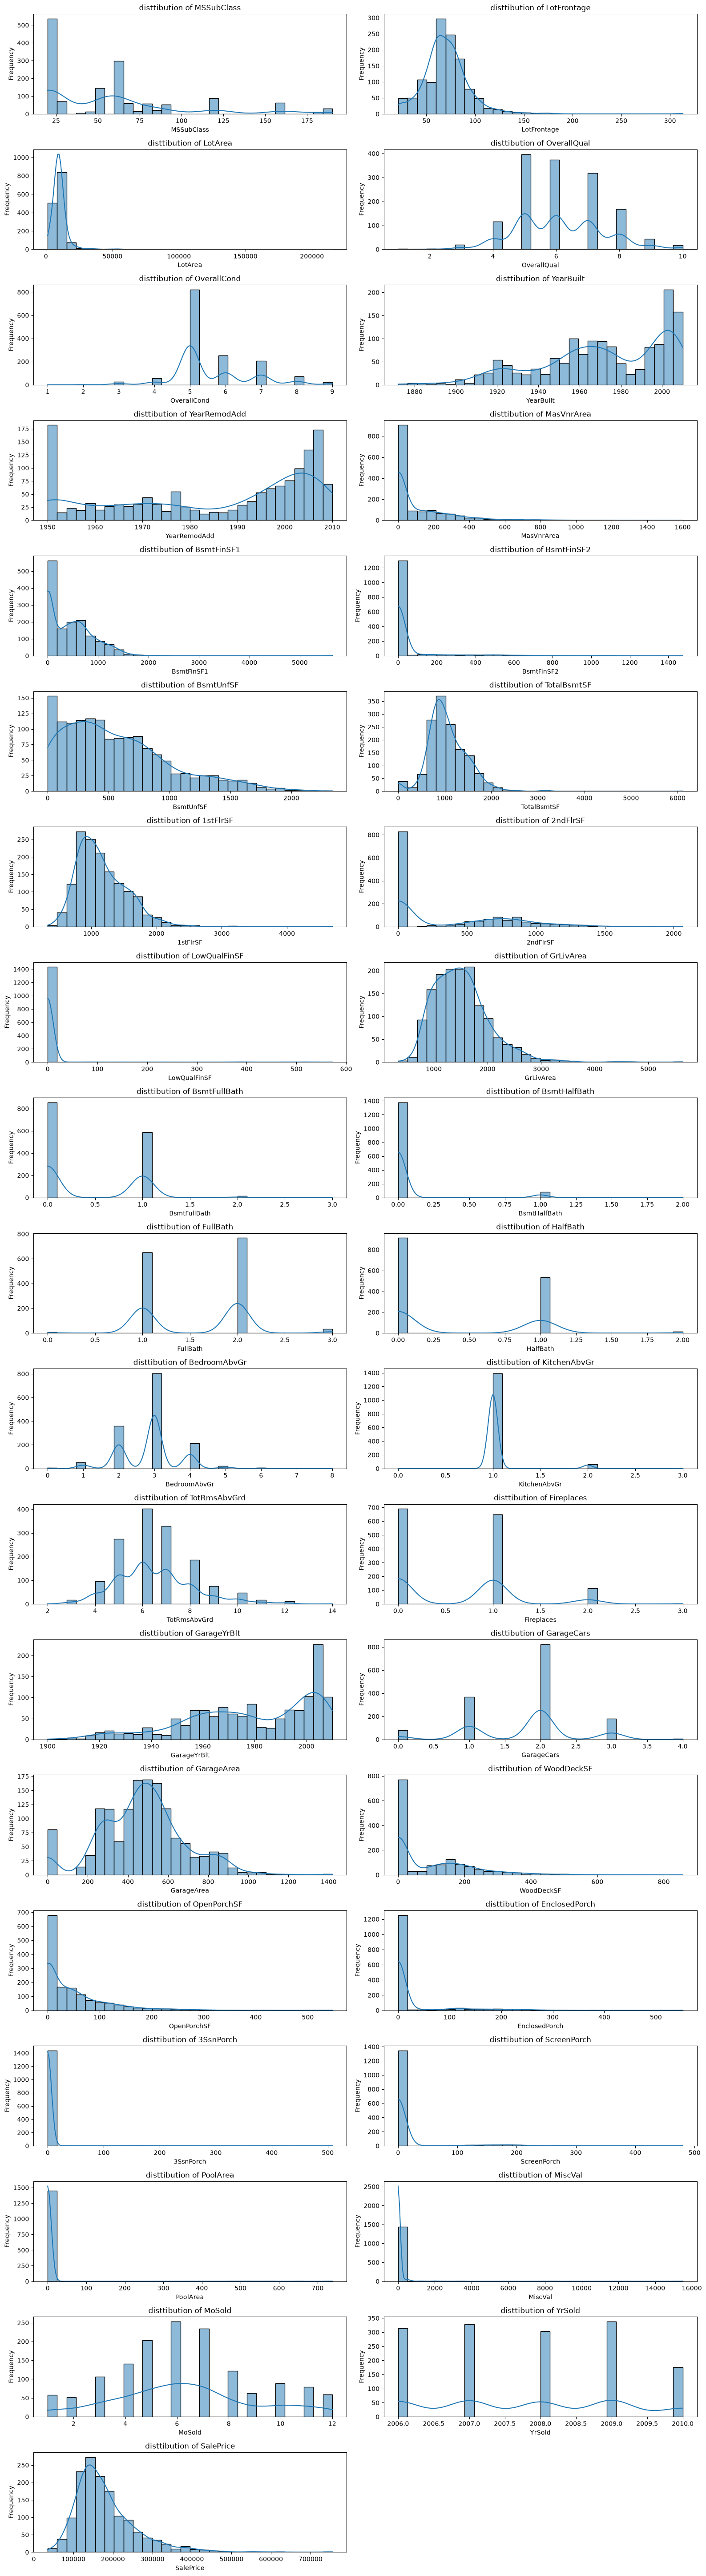

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16,58))

for i,col in enumerate(hist_cols,1) :
    plt.subplot(19,2,i)
    
    sns.histplot(data=df_tarin,x=col,bins=30,kde=True)
    plt.title(f"disttibution of {col}")
    plt.xlabel(f"{col}")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

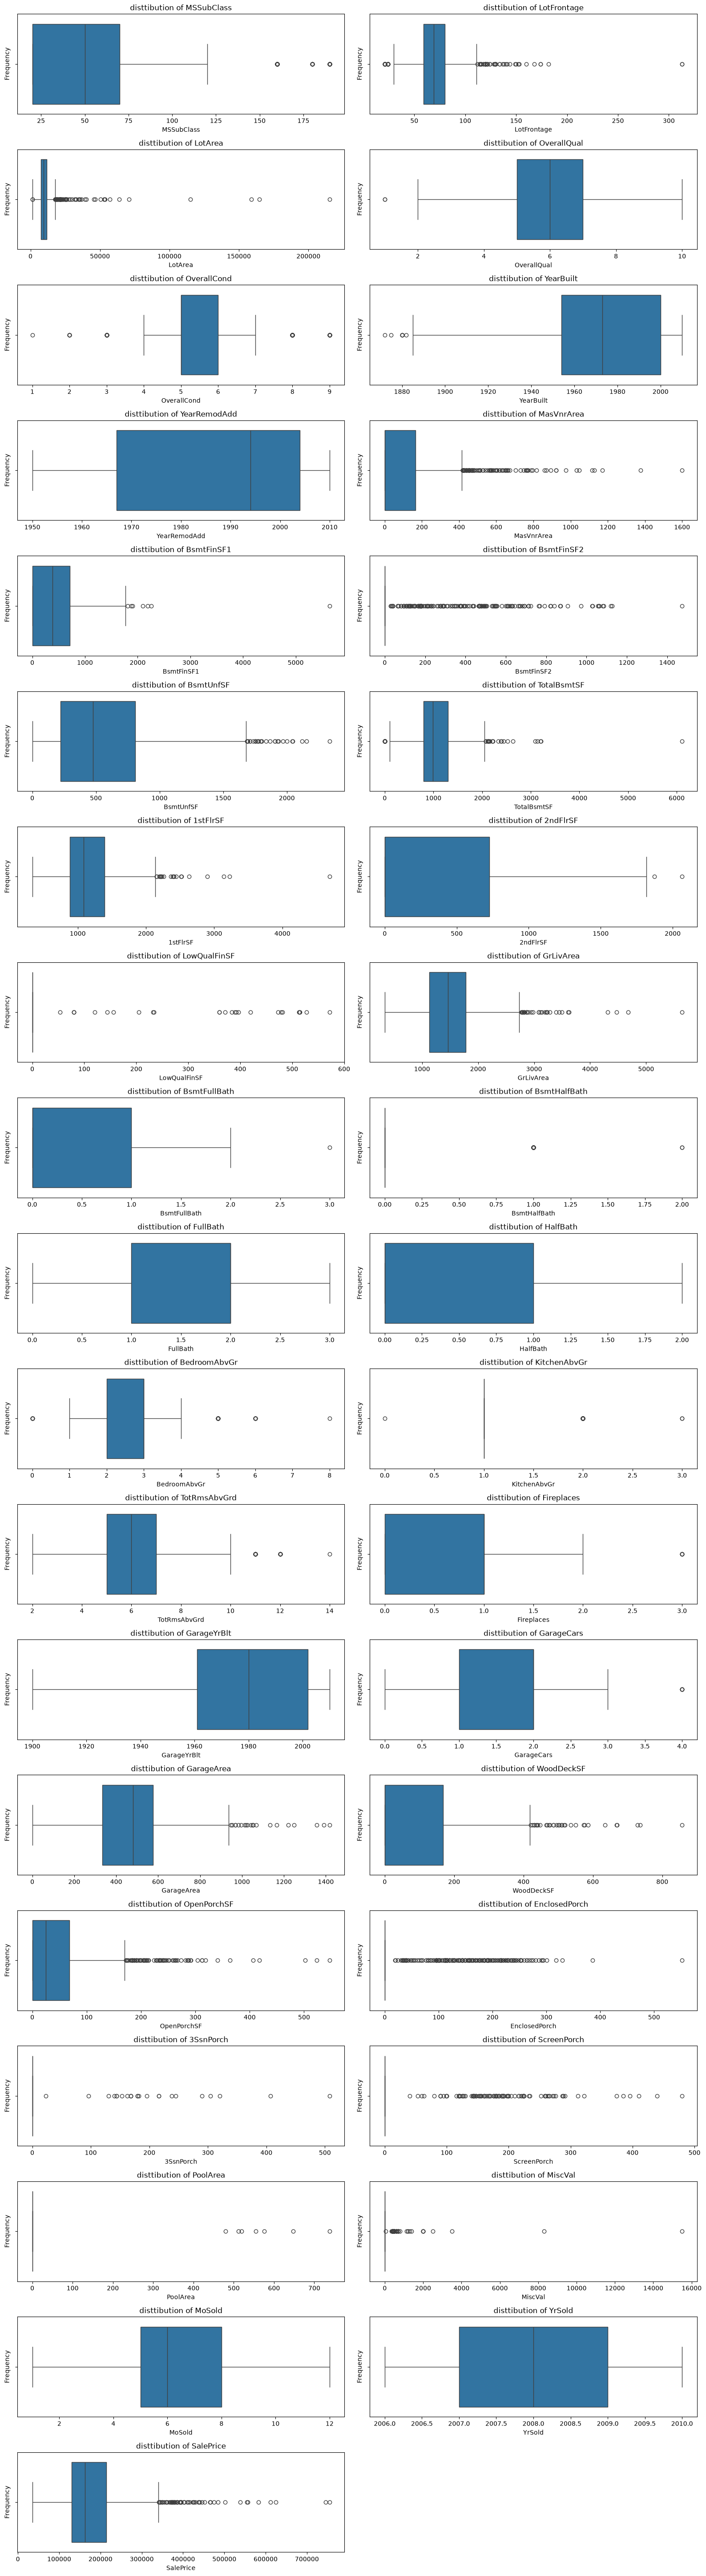

In [31]:
plt.figure(figsize=(16,58))

for i,col in enumerate(hist_cols,1) :
    plt.subplot(19,2,i)
    
    sns.boxplot(data=df_tarin,x=col)
    plt.title(f"disttibution of {col}")
    plt.xlabel(f"{col}")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

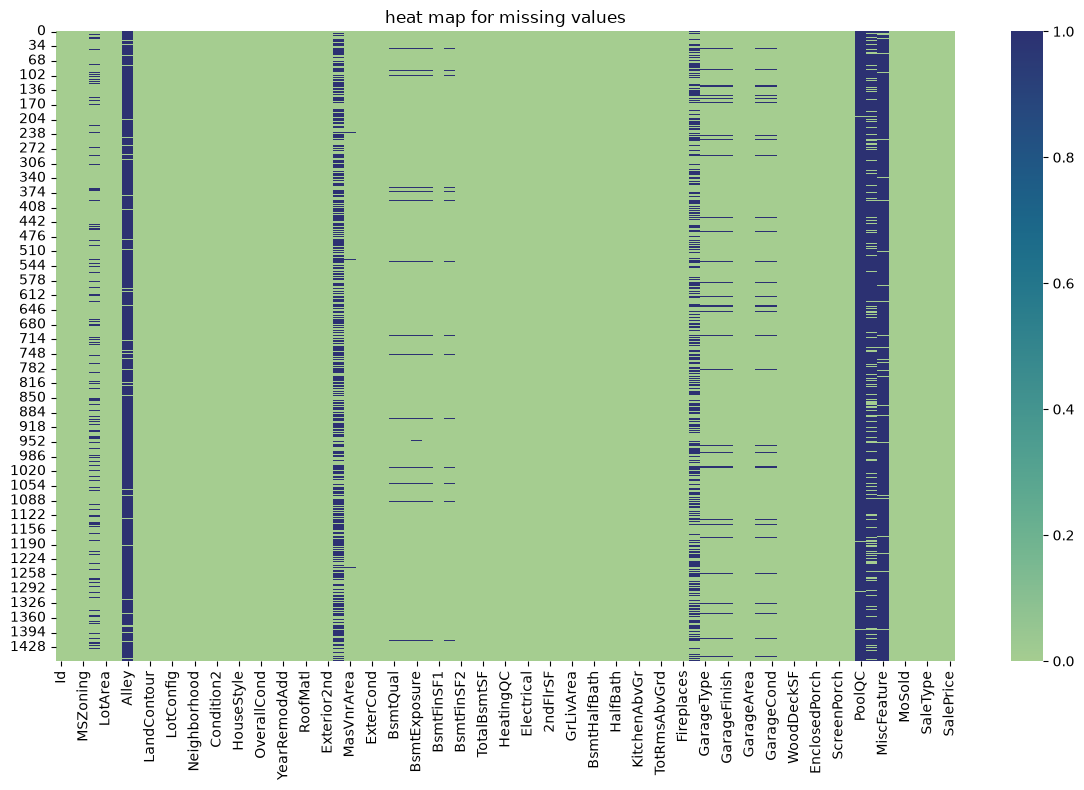

In [32]:
plt.figure(figsize=(12,8))

sns.heatmap(df_tarin.isnull(),cmap='crest')

plt.title("heat map for missing values")

plt.tight_layout()
plt.show()

In [33]:
#

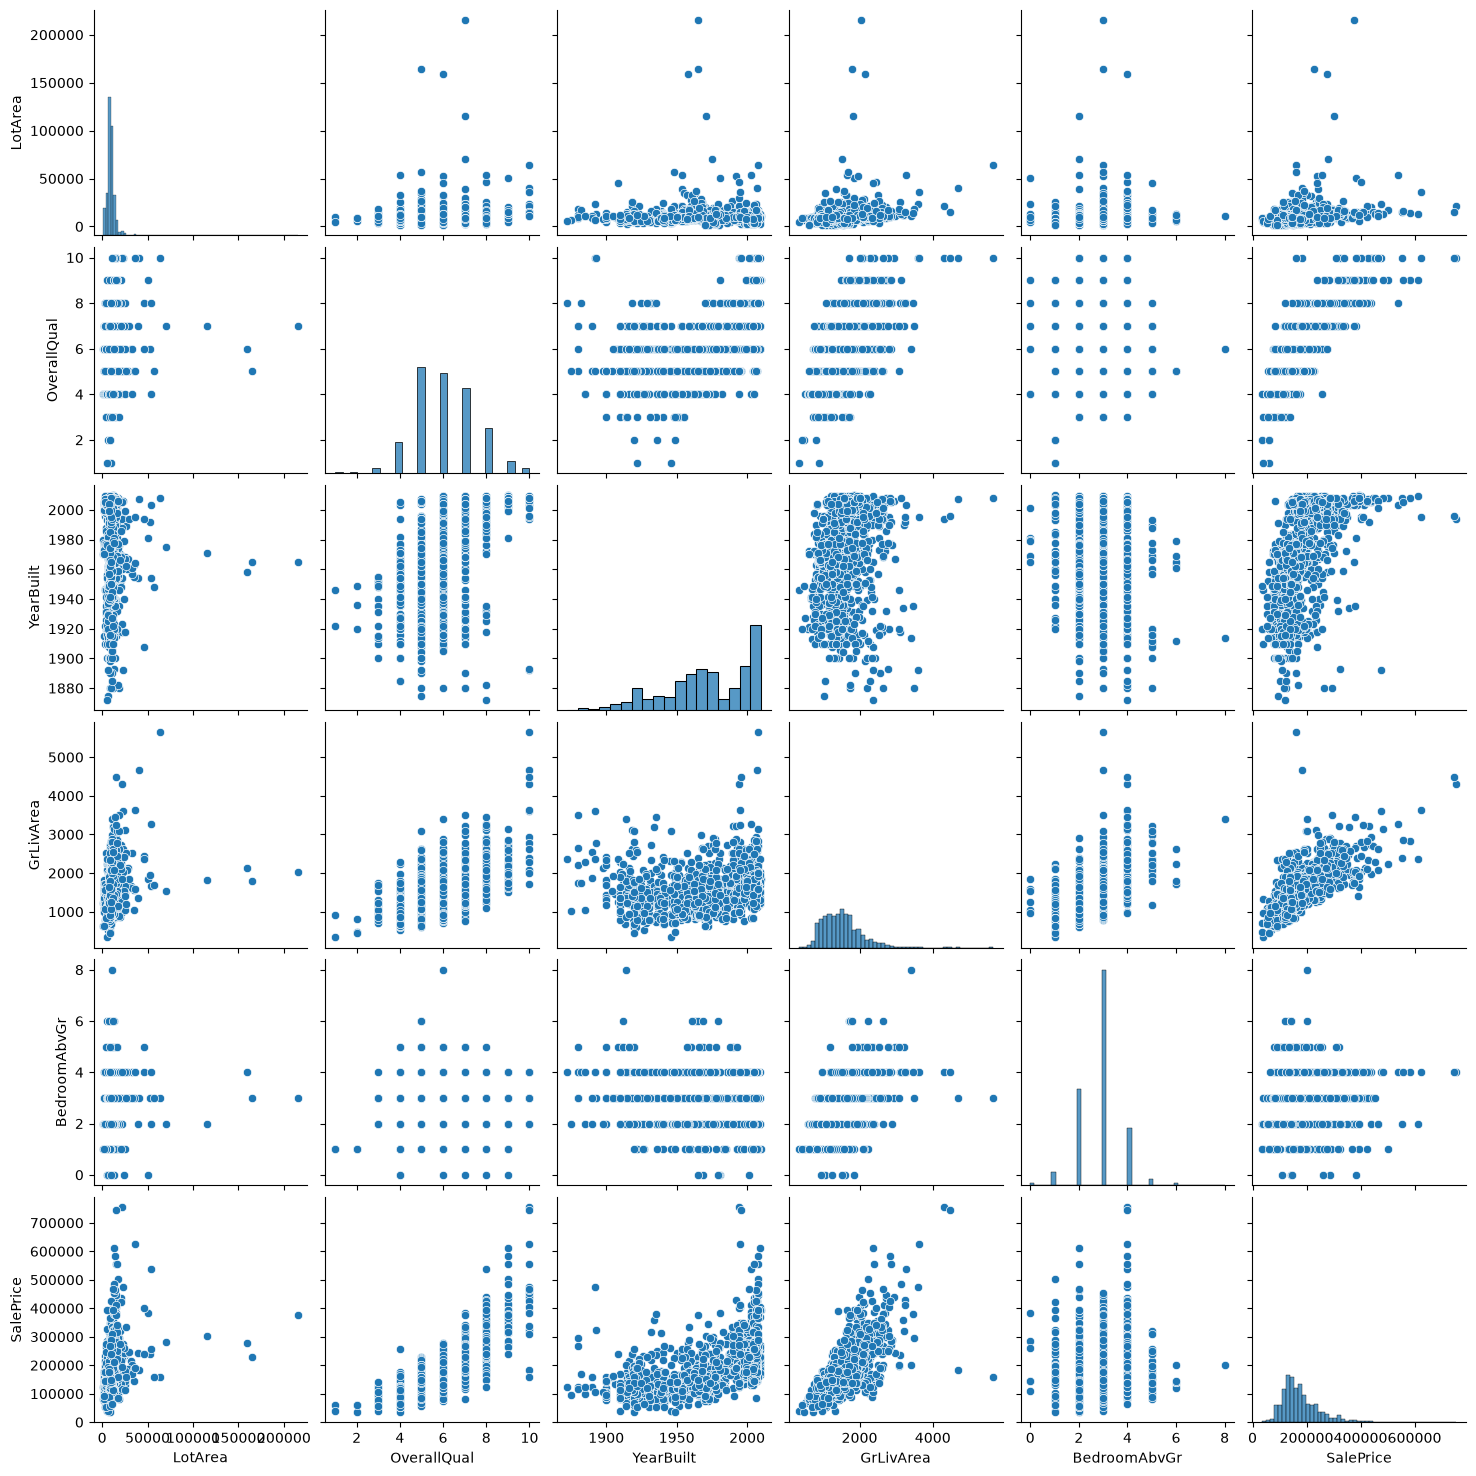

In [34]:
#pai plot
sns.pairplot(df_tarin[["LotArea","OverallQual","YearBuilt","GrLivArea","BedroomAbvGr","SalePrice"]])
plt.show()

In [35]:
corelation_matrix = df_tarin[hist_cols].corr()

corelation_matrix

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
MSSubClass,1.000000,-0.386347,-0.139781,0.032628,-0.059316,0.027850,0.040581,0.022936,-0.069836,-0.065649,...,-0.012579,-0.006100,-0.012037,-0.043825,-0.026030,0.008283,-0.007683,-0.013585,-0.021407,-0.084284
LotFrontage,-0.386347,1.000000,0.426095,0.251646,-0.059213,0.123349,0.088866,0.193458,0.233633,0.049900,...,0.088521,0.151972,0.010700,0.070029,0.041383,0.206167,0.003368,0.011200,0.007450,0.351799
LotArea,-0.139781,0.426095,1.000000,0.105806,-0.005636,0.014228,0.013788,0.104160,0.214103,0.111170,...,0.171698,0.084774,-0.018340,0.020423,0.043160,0.077672,0.038068,0.001205,-0.014261,0.263843
OverallQual,0.032628,0.251646,0.105806,1.000000,-0.091932,0.572323,0.550684,0.411876,0.239666,-0.059119,...,0.238923,0.308819,-0.113937,0.030371,0.064886,0.065166,-0.031406,0.070815,-0.027347,0.790982
OverallCond,-0.059316,-0.059213,-0.005636,-0.091932,1.000000,-0.375983,0.073741,-0.128101,-0.046231,0.040229,...,-0.003334,-0.032589,0.070356,0.025504,0.054811,-0.001985,0.068777,-0.003511,0.043950,-0.077856
YearBuilt,0.027850,0.123349,0.014228,0.572323,-0.375983,1.000000,0.592855,0.315707,0.249503,-0.049107,...,0.224880,0.188686,-0.387268,0.031355,-0.050364,0.004950,-0.034383,0.012398,-0.013618,0.522897
YearRemodAdd,0.040581,0.088866,0.013788,0.550684,0.073741,0.592855,1.000000,0.179618,0.128451,-0.067759,...,0.205726,0.226298,-0.193919,0.045286,-0.038740,0.005829,-0.010286,0.021490,0.035743,0.507101
MasVnrArea,0.022936,0.193458,0.104160,0.411876,-0.128101,0.315707,0.179618,1.000000,0.264736,-0.072319,...,0.159718,0.125703,-0.110204,0.018796,0.061466,0.011723,-0.029815,-0.005965,-0.008201,0.477493
BsmtFinSF1,-0.069836,0.233633,0.214103,0.239666,-0.046231,0.249503,0.128451,0.264736,1.000000,-0.050117,...,0.204306,0.111761,-0.102303,0.026451,0.062021,0.140491,0.003571,-0.015727,0.014359,0.386420
BsmtFinSF2,-0.065649,0.049900,0.111170,-0.059119,0.040229,-0.049107,-0.067759,-0.072319,-0.050117,1.000000,...,0.067898,0.003093,0.036543,-0.029993,0.088871,0.041709,0.004940,-0.015211,0.031706,-0.011378


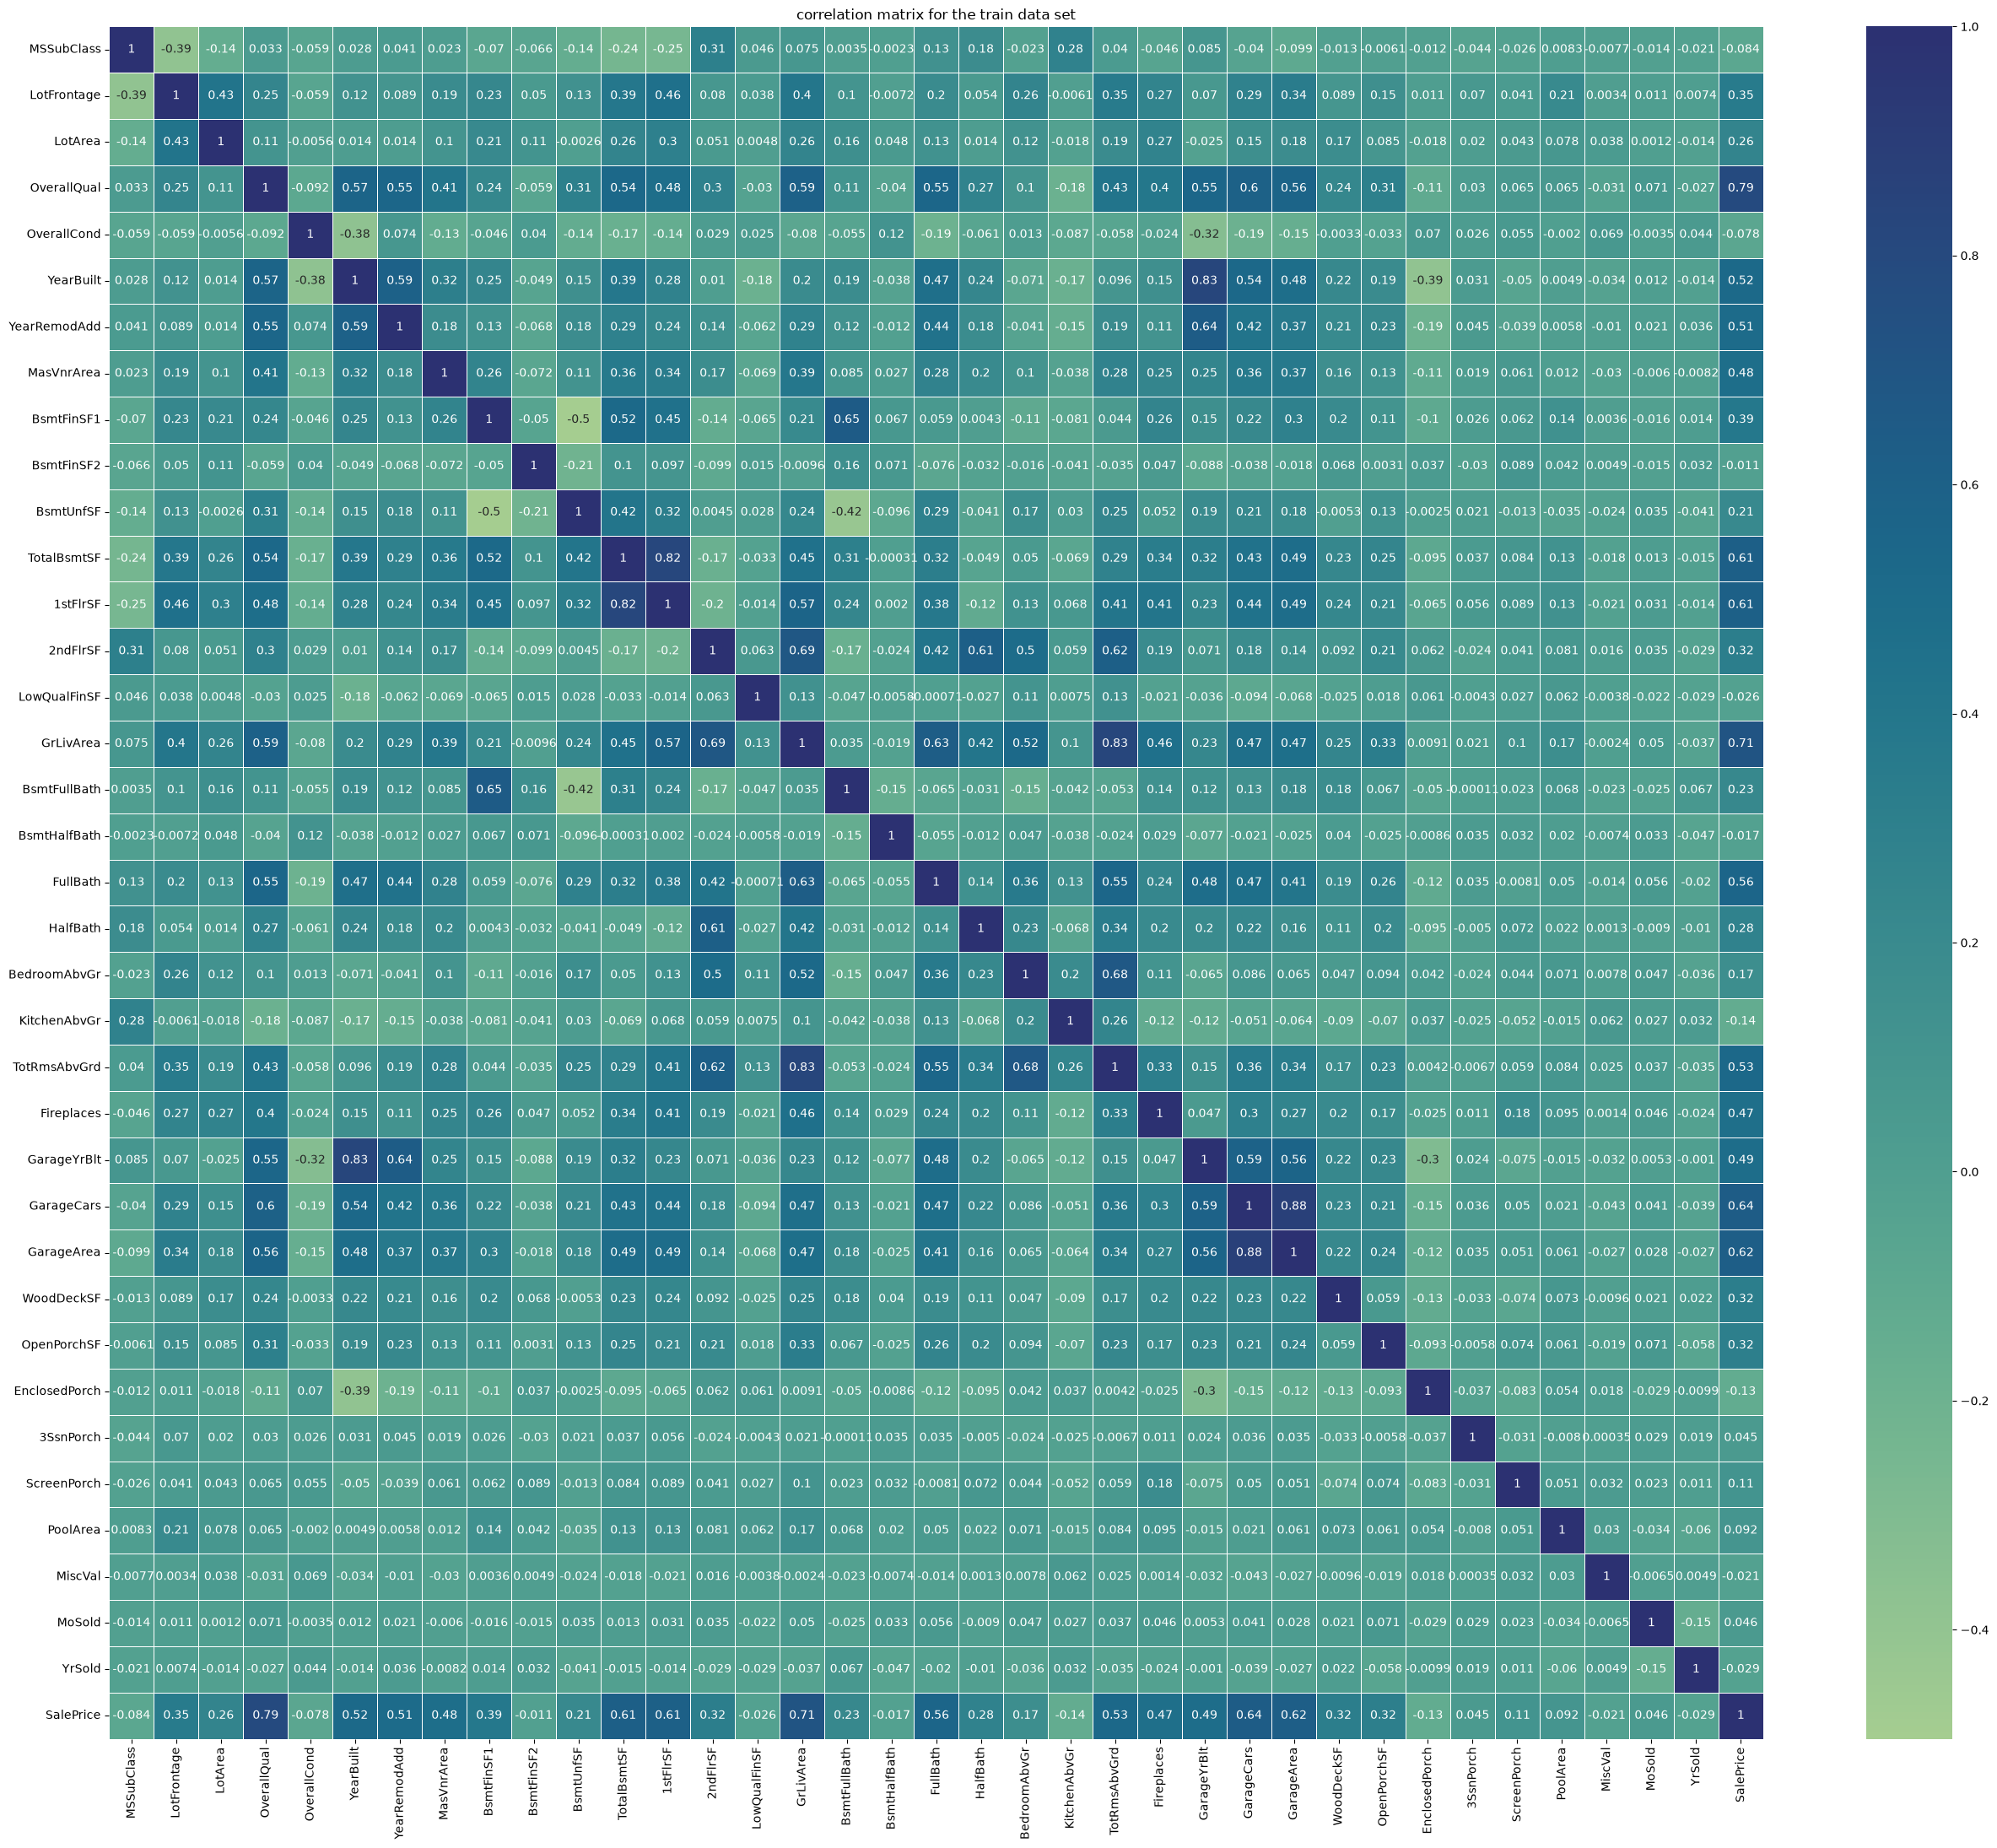

In [36]:
plt.figure(figsize=(26,22))

sns.heatmap(corelation_matrix,annot=True,cmap="crest",linewidths=0.5)

plt.title("correlation matrix for the train data set")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [37]:
"""about 37 there 14 cols greater than 0.32 relation"""

'about 37 there 14 cols greater than 0.32 relation'

In [38]:
hist_cols_test = df_test.select_dtypes(include=(int,float)).columns

hist_cols_test = list(hist_cols_test)
hist_cols_test.pop(0)
len(hist_cols_test)

36

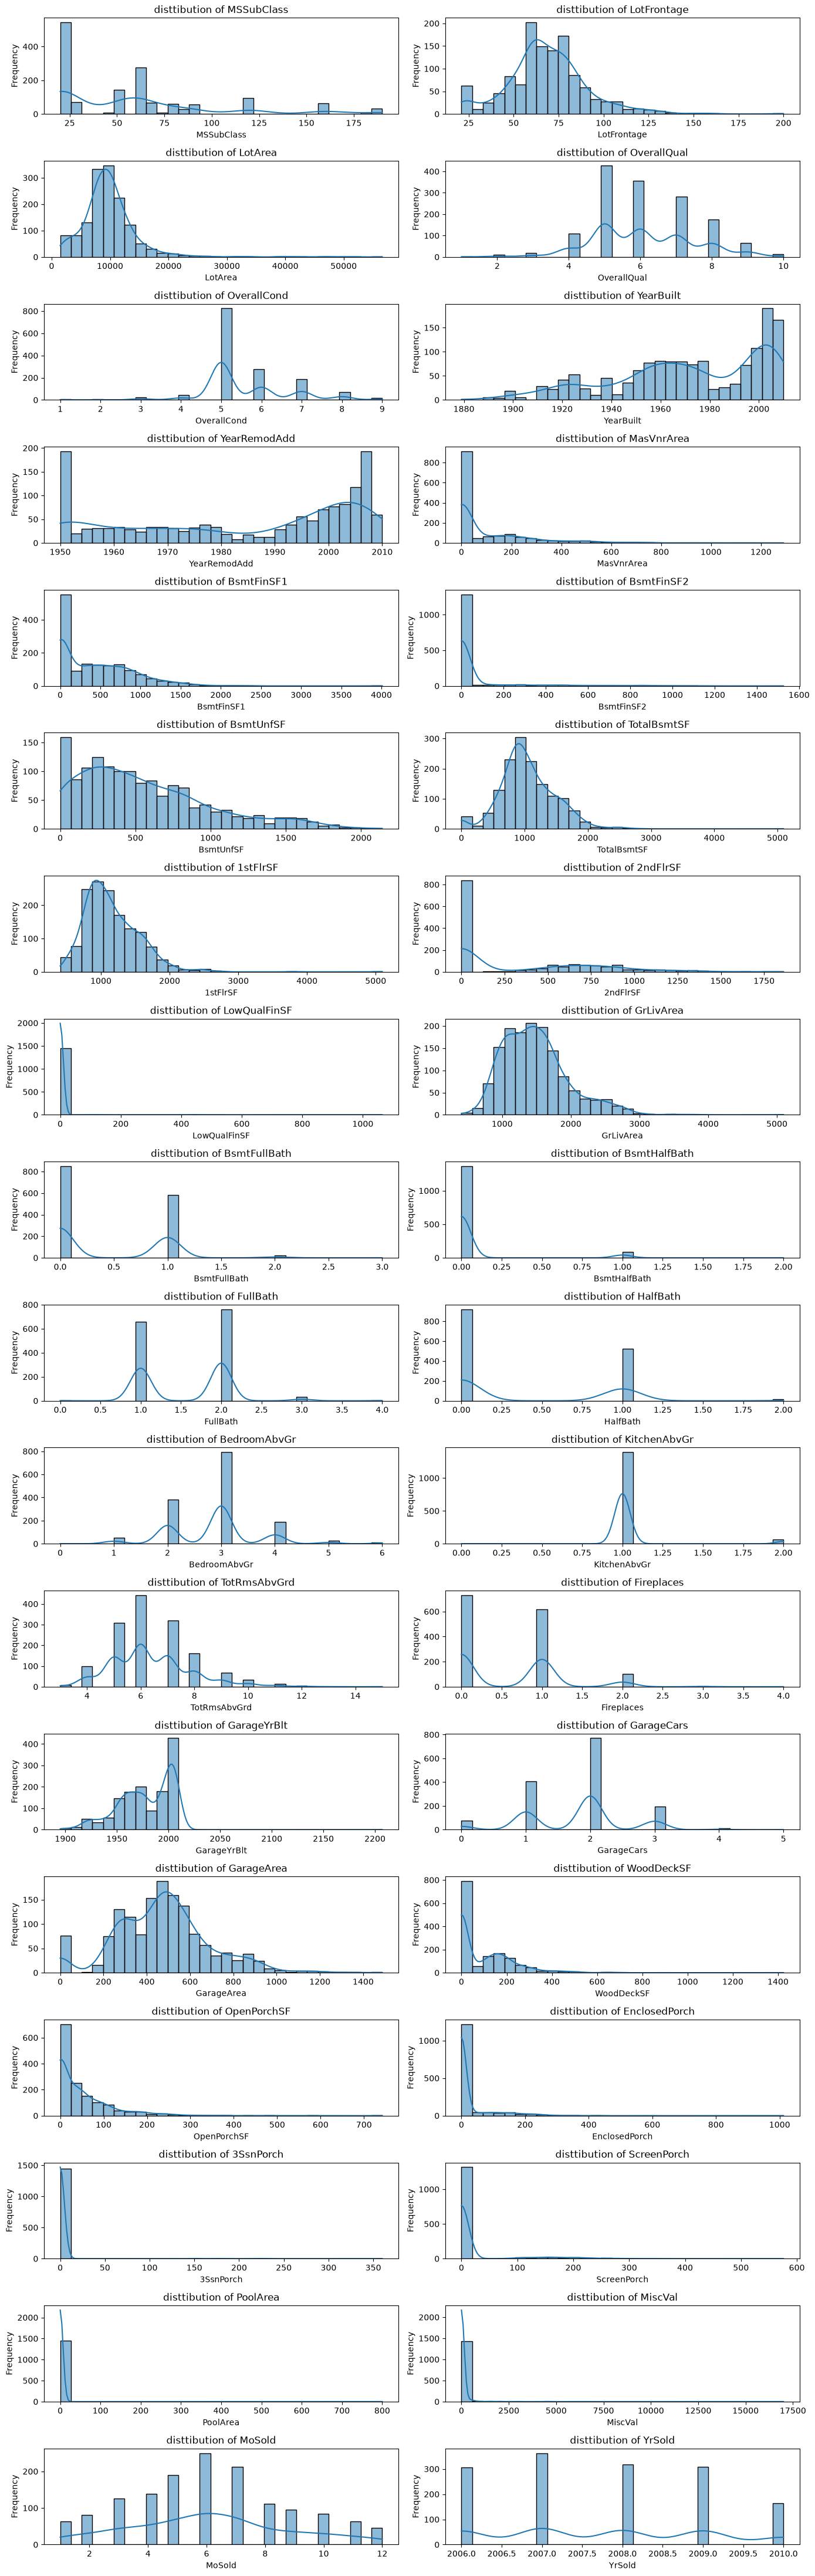

In [39]:
plt.figure(figsize=(14,46))
for i,col in enumerate(hist_cols_test,1) :
    plt.subplot(19,2,i)
    
    sns.histplot(data=df_test,x=col,bins=30,kde=True)
    plt.title(f"disttibution of {col}")
    plt.xlabel(f"{col}")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

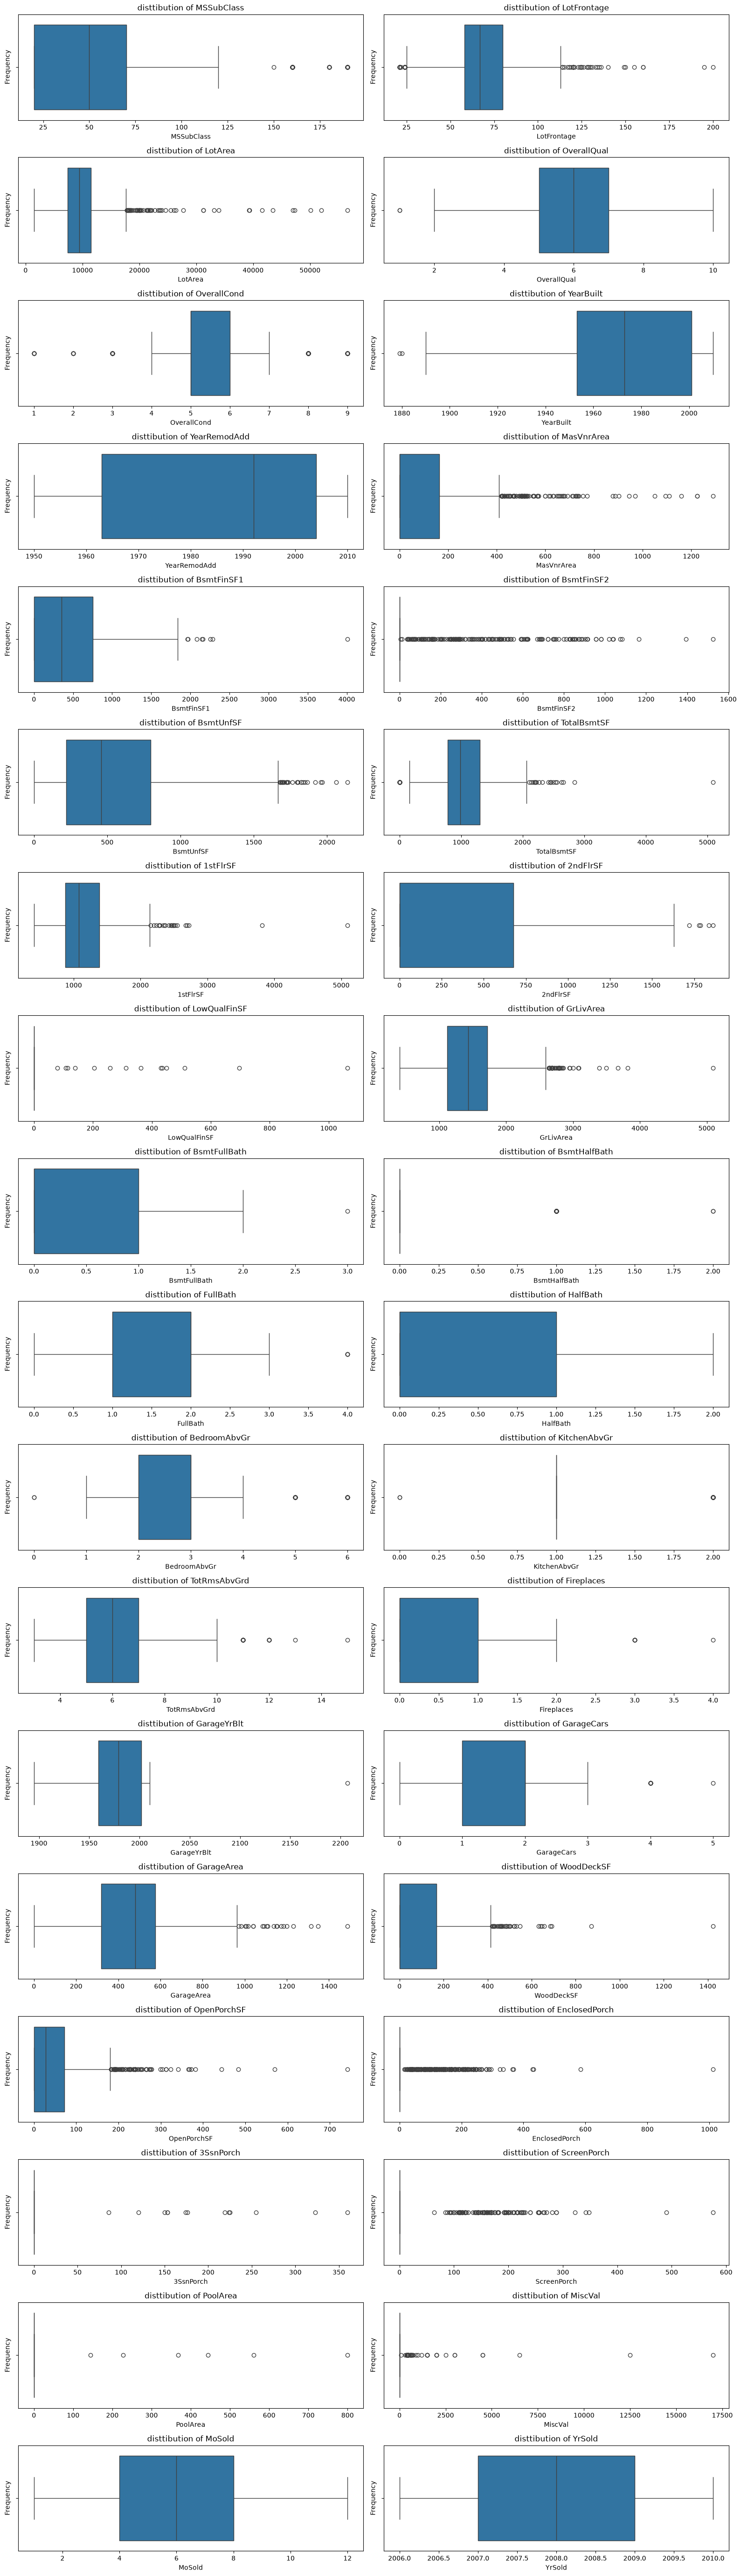

In [40]:

plt.figure(figsize=(16,58))

for i,col in enumerate(hist_cols_test,1) :
    plt.subplot(19,2,i)
    
    sns.boxplot(data=df_test,x=col)
    plt.title(f"disttibution of {col}")
    plt.xlabel(f"{col}")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

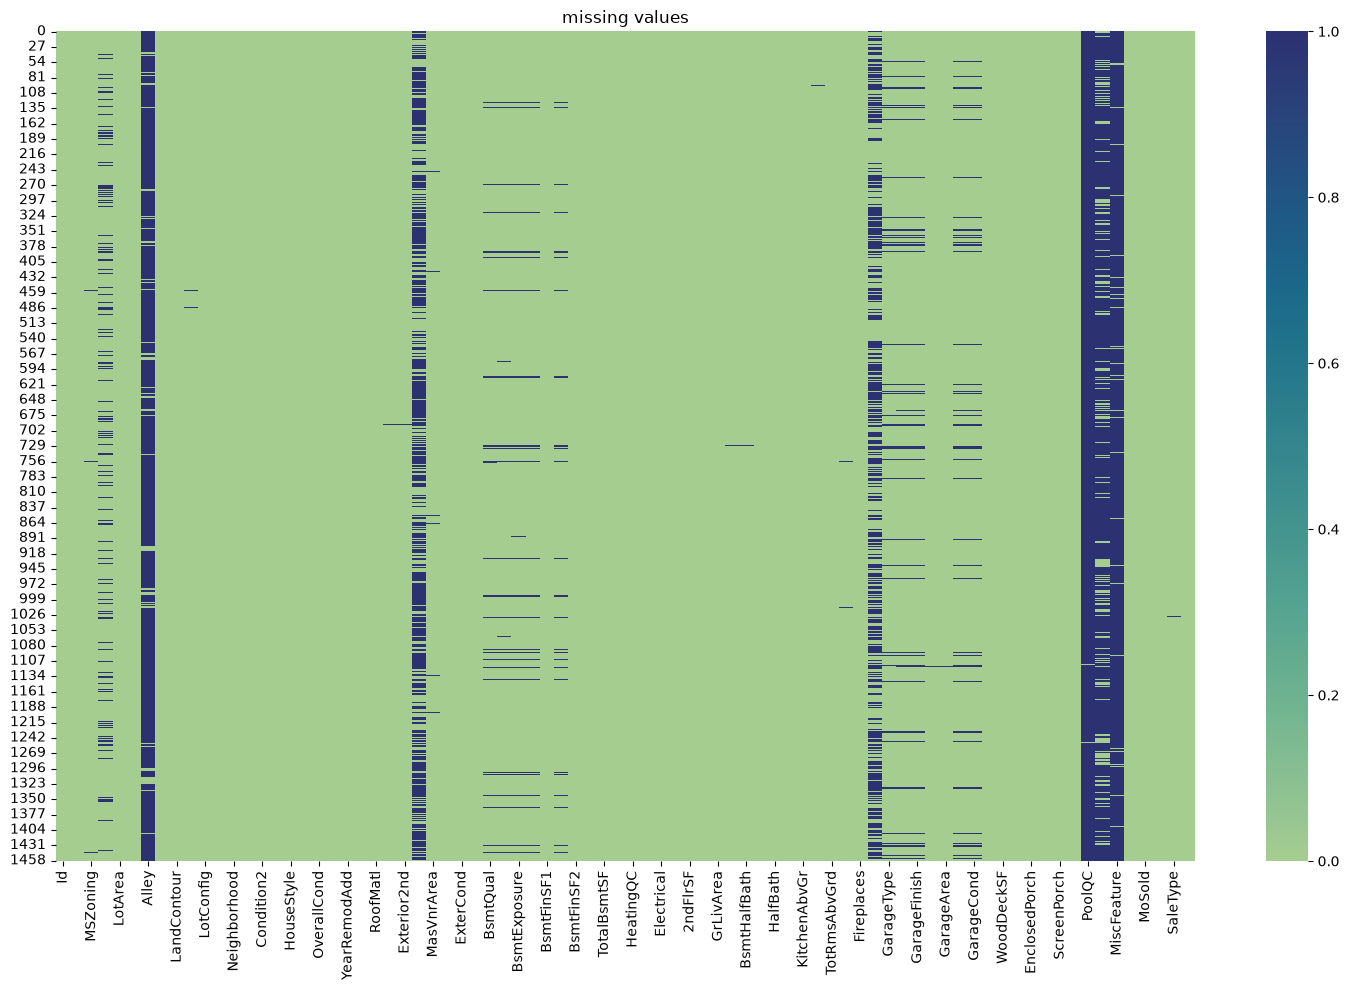

In [41]:
plt.figure(figsize=(15,10))
sns.heatmap(df_test.isnull(),cmap="crest",cbar=True)
plt.title("missing values")
plt.tight_layout()
plt.show()

In [42]:
df_tarin['EnclosedPorch']

0         0
1         0
2         0
3       272
4         0
       ... 
1455      0
1456      0
1457      0
1458    112
1459      0
Name: EnclosedPorch, Length: 1460, dtype: int64

In [43]:
df_tarin.shape[0]

1460